In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
from statsmodels.stats.multitest import multipletests

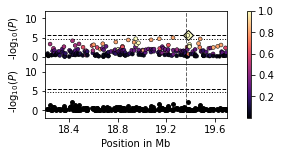

In [38]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)


start = 18200000
end = 19698289
def zooming(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df.loc[(df['chr'] == 2) &
                (df['ps'] > start) &
                (df['ps'] < end)])

full=parse('SA_leaf_B_blues.assoc.txt.gz')
classic=zooming('SA_leaf_B_blues.assoc.txt.gz')
covariate=zooming('SA_leaf_B_blues_chr2_19374681.assoc.txt.gz')

rejected, pvals_corrected, _, _ = multipletests(full['p_lrt'], alpha=0.1, method='fdr_bh')
full["Significant"] = rejected
full["FDR_corrected_pval"] = pvals_corrected

Chr2_19374681_ld=pd.read_table('chr2_19374681.ld.ld', sep = '\s+')
# Chr2_19374681_ld.head()
#Combine LD info and zoom
zoom=pd.merge(classic,Chr2_19374681_ld,left_on='ps',right_on='BP_B')
# zoom.head()

#Import color information
colors = plt.cm.magma(np.linspace(0,1,5))

def major_formatter(x, pos):
    y = x /1000000
    return "%.1f" % y

from matplotlib.gridspec import GridSpec

cm = 1/2.54
fig = plt.figure(figsize=(10*cm,5*cm))
# fig = plt.figure(figsize=(10,10))
gs = GridSpec(4, 6, figure=fig, hspace=0)
ax1 = fig.add_subplot(gs[:2,:5])
ax1=sns.scatterplot(x='ps',
                y='P',
                data=zoom,
                palette='magma',
                hue='R2',
                marker='o',
                s=15,
                linewidth=0.5,
                edgecolor='k',
                legend=False,
                zorder=2)
y_SNP = zoom.loc[zoom['ps'] == 19374681,'P'].values
ax1.plot(19374681,y_SNP,'D',markersize=7,color=colors[4],linewidth=0.5,mec='k',zorder=1)
ax1.hlines(y=-np.log10(0.05/len(full)),
             xmin=min(full['position']),
             xmax=max(full['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax1.hlines(y=full[full["Significant"] == True]['P'].min(),
             xmin=min(full['position']),
             xmax=max(full['position']),
             color='0',
             linestyle=':',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax1.set_xlim(start,end)
ax1.set_ylim(-2,12)
ax1.set_xlabel('')
ax1.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax1.set_xticklabels([])
# ax1.annotate('chr2:19374681',xy=(19374681-550000,y_SNP+3),xytext=(19374681-550000,y_SNP+3),fontsize=8)
ax1.axes.get_xaxis().set_visible(False)
# ax1.spines["bottom"].set_visible(False) 
ax1.axvline(x=19357420,linewidth=1,color='0',alpha=0.6,linestyle='--') #BOR1



ax2 = fig.add_subplot(gs[2:4,:5])
ax2=sns.scatterplot(x='ps',
                y='P',
                data=covariate,
                color='k',
                s=15,
                linewidth=1,
                edgecolor='k',
                legend=False,
                zorder=2)
ax2.hlines(y=-np.log10(0.05/len(full)),
             xmin=min(full['position']),
             xmax=max(full['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax2.hlines(y=full[full["Significant"] == True]['P'].min(),
             xmin=min(full['position']),
             xmax=max(full['position']),
             color='0',
             linestyle=':',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax2.set_xlim(start,end)
ax2.set_ylim(-2,12)
ax2.set_xlabel('')
ax2.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax2.xaxis.set_major_formatter(major_formatter)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(400000))
ax2.axvline(x=19357420,linewidth=1,color='0',alpha=0.6,linestyle='--') #BOR1

# ax2.set_yticklabels([])
ax2.set_xlabel('Position in Mb',fontsize=10)

# Add legend
norm = plt.Normalize(zoom['R2'].min(), zoom['R2'].max())
sm = plt.cm.ScalarMappable(norm=norm,cmap='magma')
sm.set_array([])
ax3 = fig.add_subplot(gs[0:4,5])
ax3.axis('off')
# ax3.get_legend().remove()
axins = inset_axes(ax3,
                    width="15%",  
                    height="100%",
                    loc='center',
                    borderpad=-5
                   )
ax3.figure.colorbar(sm,pad=0.05,shrink=0.8,cax=axins,orientation="vertical")
plt.tight_layout
plt.savefig("Fig2b.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)
# plt.savefig("Fig2b.svg", format="svg")
plt.savefig("Fig2b.pdf", format="pdf",bbox_inches="tight")